In [4]:
# import data manipualtion lkaibery

import numpy as np
import pandas as pd
# immpotr data Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt
# import warnings
import warnings
warnings.filterwarnings('ignore')
# import data logging
import logging
logging.basicConfig(filename='model.log',
                    level=logging.INFO,
                    filemode = 'w',
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    force = True)

# import scikit-learn libraries
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import classification_report,confusion_matrix


In [5]:
# data ingestion
from pathlib import Path

file_name = 'ai-impact-jobs-layoff-risk-dataset.csv'
data_path = Path.cwd() / 'data' / file_name
if not data_path.exists():
    data_path = Path.cwd().parent / 'data' / file_name

df = pd.read_csv(data_path)
print(df.shape)
print(df.columns)


(20000, 16)
Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='str')


In [6]:
# data preprocessing

# Remove duplicate rows and target-only columns for clustering.
df = df.drop_duplicates().copy()
df = df.drop(columns=['AI_Adoption_Level', 'Layoff_Risk'])

# Encode categorical columns before clustering.
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    df[column] = LabelEncoder().fit_transform(df[column])

# Split the dataset for fitting and evaluating clusters.
X_train, X_test = train_test_split(
    df.copy(),
    test_size=0.3,
    random_state=42
)


In [7]:
# data modeling
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3).fit(X_train)   # seen data
cluster = kmeans.predict(X_train)


In [20]:
# Add cluster predictions to the matching test rows.
df.loc[X_test.index, 'cluster'] = kmeans.predict(X_test)


Text(0.5, 1.0, 'Pie Plot Showing Cluster Distribution')

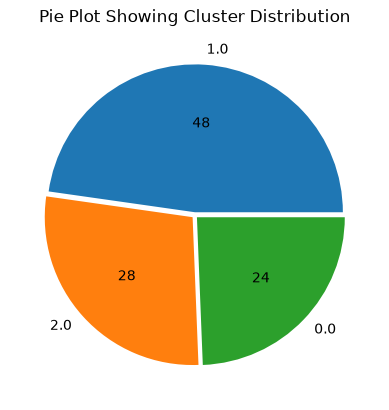

In [17]:
df['cluster'].value_counts().plot(kind = 'pie',
                                  autopct = '%0.0f',
                                  explode = [0.02,0.02,0.02])
plt.title('Pie Plot Showing Cluster Distribution')

In [18]:
# Segregate High Prioriy People Data and Low Priority People Data

High_Priority = df[df['cluster'] == 1]
High_Priority['Education_Level'].value_counts()

Education_Level
0    1397
2     731
1     558
3     179
Name: count, dtype: int64